<div style='background: linear-gradient(135deg,#1a1a2e 0%,#16213e 60%,#0f3460 100%); padding:48px 40px 36px; border-radius:12px; margin-bottom:8px;'>
  <h1 style='color:#e2e8f0; font-size:2.2em; margin:0 0 8px; font-weight:700; letter-spacing:-0.5px;'>
    Sparse Linear System Solvers
  </h1>
  <p style='color:#94a3b8; font-size:1.1em; margin:0 0 24px;'>
    LU Factorization · Iterative Methods · Preconditioning
  </p>
  <div style='display:flex; gap:12px; flex-wrap:wrap;'>
    <span style='background:#0f3460; color:#60a5fa; padding:4px 14px; border-radius:20px; font-size:0.82em; border:1px solid #1e40af;'>NumPy / SciPy</span>
    <span style='background:#0f3460; color:#34d399; padding:4px 14px; border-radius:20px; font-size:0.82em; border:1px solid #065f46;'>Sparse Matrices</span>
    <span style='background:#0f3460; color:#f472b6; padding:4px 14px; border-radius:20px; font-size:0.82em; border:1px solid #9d174d;'>Numerical Analysis</span>
  </div>
</div>


## Overview

This project benchmarks three complementary approaches for solving large sparse symmetric positive-definite (SPD) linear systems $Ax = b$:

| Module | Topic | Key metric |
|--------|-------|------------|
| **1** | Sparse LU Factorization | Fill-in, condition number, forward error |
| **2** | Jacobi & Conjugate Gradient | Convergence rate vs. conditioning |
| **3** | Preconditioned CG (PCG) | Iteration reduction via Jacobi preconditioner |

Test matrices are drawn from the [SuiteSparse Matrix Collection](https://sparse.tamu.edu/), a standard benchmark suite in scientific computing.


---
## 0 · Dependencies & Utility Functions


All helper metrics used throughout the project are defined here once and imported by reference in later sections.

**Relative error norm** - used in Part 1:
$$\text{rel\_error\_norm}(x, \hat{x}) = \frac{\|x - \hat{x}\|_1}{\|x\|_1}$$

**Relative residual norm** - used in Part 1:
$$\text{rel\_residual\_norm}(A, \hat{x}, b) = \frac{\|A\hat{x} - b\|_1}{\|A\|_1 \cdot \|\hat{x}\|_1}$$

**Relative residual norm (iterative)** - used in Parts 2 & 3:
$$\text{rel\_residual\_norm\_iter}(A, \hat{x}, b) = \frac{\|A\hat{x} - b\|_2}{\|b\|_2}$$

**Condition number** - used in Parts 1 & 3:
$$\text{cond\_1}(A) = \|A\|_1 \cdot \|A^{-1}\|_1$$

In [1]:
import warnings
import os
import tarfile
import requests
from os.path import exists
from pathlib import Path
from typing import Tuple

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.sparse.linalg import splu, cg, norm, inv

# ── Plot theme ───────────────────────────────────
mpl.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'axes.titlecolor':  '#e2e8f0',
    'xtick.color':      '#64748b',
    'ytick.color':      '#64748b',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'text.color':       '#94a3b8',
    'legend.facecolor': '#1e293b',
    'legend.edgecolor': '#334155',
    'legend.labelcolor':'#cbd5e1',
    'figure.dpi':       110,
})
COLORS = ['#60a5fa', '#f472b6', '#34d399', '#fb923c', '#a78bfa']


In [2]:
# ── Metric helpers ──────────────────────────────────

def rel_residual_norm(A: sp.sparse.spmatrix, x_hat: np.ndarray, b: np.ndarray) -> float:
    """1-norm relative residual  ||Ax̂ - b||₁ / (||A||₁ ||x̂||₁).  Used in Part 1."""
    if not sp.sparse.issparse(A):
        raise TypeError('Matrix A must be sparse')
    if not all(isinstance(p, np.ndarray) for p in [x_hat, b]):
        raise TypeError('x_hat and b must be numpy arrays')
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError('Matrix A must be square')
    if x_hat.ndim != 1 or b.ndim != 1:
        raise ValueError('Vectors must be 1-D')
    xn = np.linalg.norm(x_hat, ord=1)
    if xn == 0:
        warnings.warn('rel_residual_norm: ||x̂||₁ = 0, returning NaN.')
        return np.nan
    return np.linalg.norm(A.dot(x_hat) - b, ord=1) / (sp.sparse.linalg.norm(A, ord=1) * xn)


def rel_residual_norm_iter(A: sp.sparse.spmatrix, x_hat: np.ndarray, b: np.ndarray) -> float:
    """2-norm relative residual  ||Ax̂ - b||₂ / ||b||₂.  Used in Parts 2 & 3."""
    if not sp.sparse.issparse(A):
        raise TypeError('Matrix A must be sparse')
    if not all(isinstance(p, np.ndarray) for p in [x_hat, b]):
        raise TypeError('x_hat and b must be numpy arrays')
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError('Matrix A must be square')
    if x_hat.ndim != 1 or b.ndim != 1:
        raise ValueError('Vectors must be 1-D')
    bn = np.linalg.norm(b, ord=2)
    if bn == 0:
        warnings.warn('rel_residual_norm_iter: ||b||₂ = 0, returning NaN.')
        return np.nan
    return np.linalg.norm(A.dot(x_hat) - b, ord=2) / bn


def rel_error_norm(x: np.ndarray, x_hat: np.ndarray) -> float:
    """1-norm relative forward error  ||x - x̂||₁ / ||x||₁."""
    if not all(isinstance(p, np.ndarray) for p in [x, x_hat]):
        raise TypeError('x and x_hat must be numpy arrays')
    if x.shape != x_hat.shape:
        raise ValueError('x and x_hat must have the same shape')
    return np.linalg.norm(x_hat - x, ord=1) / np.linalg.norm(x, ord=1)


def cond_1(A: sp.sparse.spmatrix) -> float:
    """1-norm condition number  κ₁(A) = ||A||₁ · ||A⁻¹||₁."""
    return norm(A, ord=1) * norm(inv(A), ord=1)


print('✓  All utility functions loaded.')


✓  All utility functions loaded.


### 0.1 · Test Matrix Acquisition

Sparse benchmark matrices are fetched from the [SuiteSparse Matrix Collection](https://sparse.tamu.edu/).

| Group | Matrices | Application domain |
|-------|----------|--------------------|
| Parts 1 & 2 | `mesh2e1`, `bcsstk20` | FEM mesh / structural engineering |
| Part 3 | `nos5`, `msc00726` | Structural / aerospace |


In [3]:
def _download(source: Path, dest: Path = Path('./')) -> Path:
    dest = Path(dest, str(source).split('/')[-1])
    if exists(dest):
        return dest
    r = requests.get(source, allow_redirects=True)
    r.raise_for_status()
    dest.write_bytes(r.content)
    return dest

def _decompress(fp, out='.'):
    with tarfile.open(fp, 'r:gz') as tar:
        tar.extractall(path=out, filter='data')
    base = os.path.splitext(os.path.splitext(os.path.basename(fp))[0])[0]
    return os.path.join(out, base)

def _find_mtx(directory):
    for root, _, files in os.walk(directory):
        for f in files:
            if f.endswith('.mtx') and not f.endswith('coord.mtx'):
                return os.path.join(root, f)
    raise FileNotFoundError('No .mtx file found.')

def _load(url):
    return sp.io.mmread(_find_mtx(_decompress(_download(url)))).tocsc()

URLS_1 = [
    'https://suitesparse-collection-website.herokuapp.com/MM/Pothen/mesh2e1.tar.gz',
    'https://suitesparse-collection-website.herokuapp.com/MM/HB/bcsstk20.tar.gz',
]
URLS_2 = [
    'https://suitesparse-collection-website.herokuapp.com/MM/HB/nos5.tar.gz',
    'https://suitesparse-collection-website.herokuapp.com/MM/Boeing/msc00726.tar.gz',
]

matrices_1 = [_load(u) for u in URLS_1]
matrices_2 = [_load(u) for u in URLS_2]

names_1 = ['mesh2e1', 'bcsstk20']
names_2 = ['nos5', 'msc00726']

print('Matrix         Shape          nnz')
print('-' * 40)
for name, M in zip(names_1 + names_2, matrices_1 + matrices_2):
    print(f'{name:<14} {str(M.shape):<14} {M.nnz:>8,}')


Matrix         Shape          nnz
----------------------------------------
mesh2e1        (306, 306)        2,018
bcsstk20       (485, 485)        3,135
nos5           (468, 468)        5,172
msc00726       (726, 726)       34,518


## 1 · Sparse LU Factorization

Sparse LU factorization decomposes $A = P L U Q$ where $P, Q$ are permutation matrices, $L$ is unit lower-triangular, and $U$ is upper-triangular. The choice of column ordering dramatically affects *fill-in* - the number of new non-zeros created during factorization.


### 1.1 · Fill-in Analysis: Natural vs. COLAMD Ordering

**COLAMD** (Column Approximate Minimum Degree) reorders columns to minimise the expected fill-in. Natural ordering uses no reordering and typically produces far denser factors.


Fill-in analysis for mesh2e1  (original nnz = 2,018)
Factor                    nnz     ratio
----------------------------------------
Original A              2,018         —
L  (Natural)           12,101      6.0×
U  (Natural)           12,101      6.0×
L  (COLAMD)             4,551      2.3×
U  (COLAMD)             4,551      2.3×


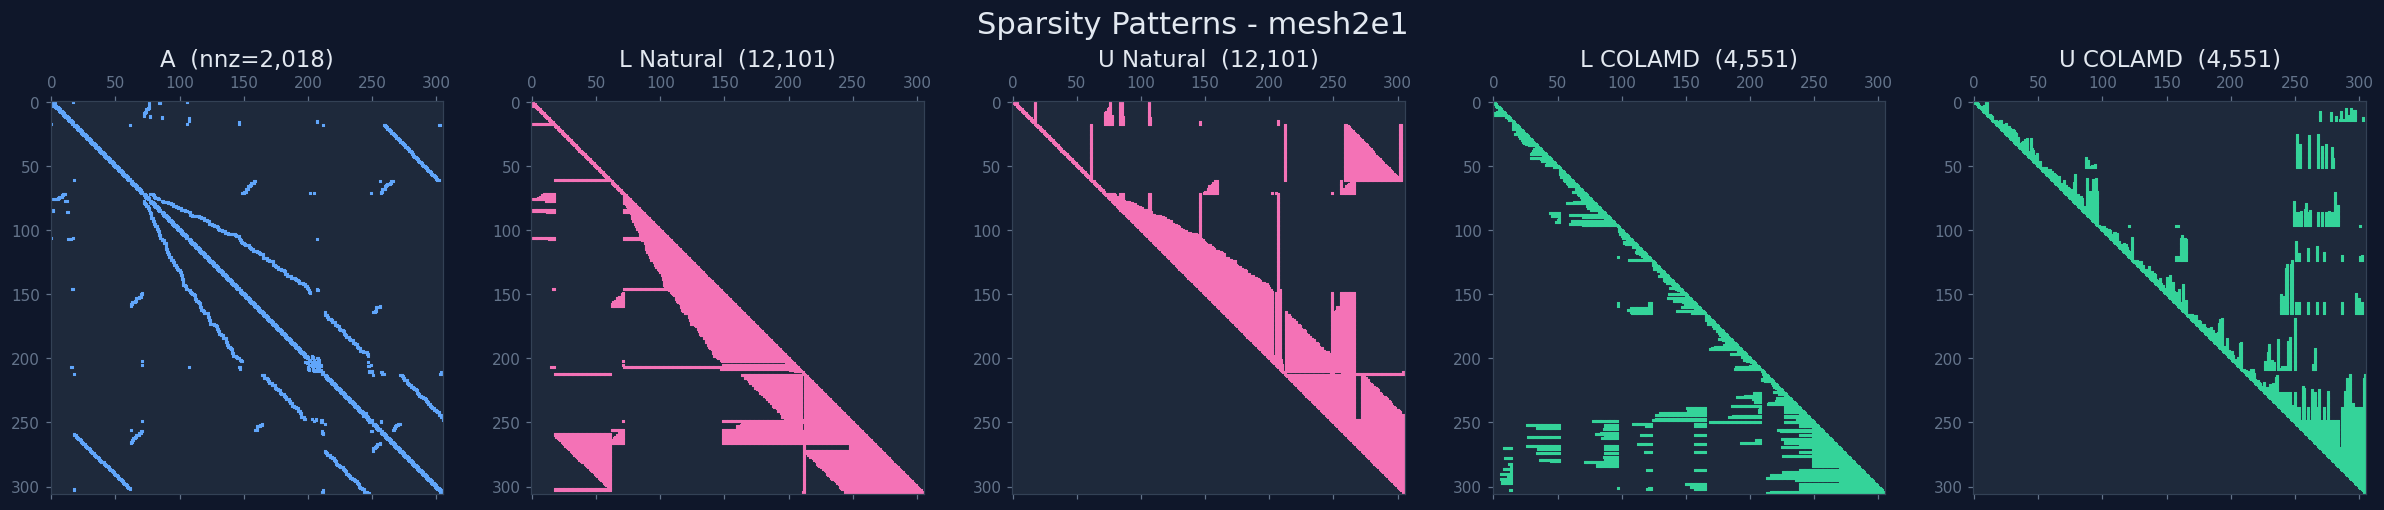

In [4]:
A = matrices_1[0]   # mesh2e1

lu_nat   = splu(A, permc_spec='NATURAL')
lu_col   = splu(A, permc_spec='COLAMD')

# ── Summary table ───────────────────────────────────
rows = [
    ('Original A',      A.nnz,          '—'),
    ('L  (Natural)',    lu_nat.L.nnz,   f'{lu_nat.L.nnz / A.nnz:.1f}×'),
    ('U  (Natural)',    lu_nat.U.nnz,   f'{lu_nat.U.nnz / A.nnz:.1f}×'),
    ('L  (COLAMD)',     lu_col.L.nnz,   f'{lu_col.L.nnz / A.nnz:.1f}×'),
    ('U  (COLAMD)',     lu_col.U.nnz,   f'{lu_col.U.nnz / A.nnz:.1f}×'),
]
print(f'Fill-in analysis for mesh2e1  (original nnz = {A.nnz:,})')
print(f'{"Factor":<18} {"nnz":>10}  {"ratio":>8}')
print('-' * 40)
for label, nnz, ratio in rows:
    print(f'{label:<18} {nnz:>10,}  {ratio:>8}')

# ── Sparsity pattern plots ───────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
fig.patch.set_facecolor('#0f172a')

specs = [
    (A,           f'A  (nnz={A.nnz:,})',               '#60a5fa'),
    (lu_nat.L,    f'L Natural  ({lu_nat.L.nnz:,})',    '#f472b6'),
    (lu_nat.U,    f'U Natural  ({lu_nat.U.nnz:,})',    '#f472b6'),
    (lu_col.L,    f'L COLAMD  ({lu_col.L.nnz:,})',     '#34d399'),
    (lu_col.U,    f'U COLAMD  ({lu_col.U.nnz:,})',     '#34d399'),
]
for ax, (mat, title, color) in zip(axes, specs):
    ax.spy(mat, markersize=1, color=color)
    ax.set_title(title, fontsize=15, pad=6)
    ax.set_facecolor('#1e293b')
    for spine in ax.spines.values():
        spine.set_edgecolor('#334155')

fig.suptitle('Sparsity Patterns - mesh2e1', fontsize=20, color='#e2e8f0', y=1.01)
plt.tight_layout()
plt.show()


### 1.2 · Accuracy vs. Condition Number

The standard error bound relates backward stability to conditioning:

$$\frac{\|x - \hat{x}\|}{\|x\|} \lesssim \kappa_1(A) \cdot \frac{\|b - A\hat{x}\|}{\|A\| \cdot \|\hat{x}\|}$$

A small residual is **necessary but not sufficient** for accuracy - the condition number amplifies any residual into a forward error.

In [5]:
print(f'{"Matrix":<12} {"Rel. Residual":>16} {"Rel. Fwd Error":>16} {"κ₁(A)":>14}')
print('-' * 62)

for name, A in zip(names_1, matrices_1):
    x_exact = np.ones(A.shape[0])
    b = A.dot(x_exact)
    lu = splu(A, permc_spec='COLAMD')
    x_hat = lu.solve(b)

    r = rel_residual_norm(A, x_hat, b)
    e = rel_error_norm(x_exact, x_hat)
    k = cond_1(A)
    print(f'{name:<12} {r:>16.4e} {e:>16.4e} {k:>14.4e}')


Matrix          Rel. Residual   Rel. Fwd Error          κ₁(A)
--------------------------------------------------------------
mesh2e1            1.1585e-17       2.0742e-15     4.2433e+02
bcsstk20           1.2929e-18       1.2174e-08     7.4834e+12


### 1.3 · Interpretation

**Key observation:** LU factorization is *backward stable*: both matrices produce a residual at the level of machine epsilon (~10⁻¹⁷). However, the forward errors diverge dramatically.

- **`mesh2e1`** ($\kappa \approx 4\times10^2$): the forward error ($\sim10^{-15}$) nearly matches machine precision - only ~3 digits are lost ($\log_{10}\kappa \approx 3$).
- **`bcsstk20`** ($\kappa \approx 7\times10^{12}$): the forward error degrades to ~$10^{-8}$, losing ~12 digits of precision - exactly as predicted by the bound ($\log_{10}\kappa \approx 13$).

> **Takeaway:** Always inspect $\kappa(A)$ before trusting a small residual as a proxy for accuracy in ill-conditioned systems.


---
## 2 · Iterative Solvers: Jacobi & Conjugate Gradient

Iterative methods avoid the memory cost of explicit LU factors. Their convergence rate depends critically on the condition number $\kappa(A)$.


### 2.1 · Jacobi Method

The matrix form of the Jacobi iteration avoids dense component-wise loops:
$$x^{(k+1)} = D^{-1}\\bigl(b - (L+U)\\,x^{(k)}\\bigr)$$
where $D = \\operatorname{diag}(A)$ and $(L+U) = A - D$. Sparsity is exploited by computing $A x^{(k)}$ via sparse matrix-vector product then subtracting $D x^{(k)}$.


In [6]:
def jacobi(
    A: sp.sparse.spmatrix,
    b: np.ndarray,
    tol: float,
    maxit: int,
    x0: np.ndarray,
) -> Tuple[np.ndarray, int, np.ndarray]:
    """
    Sparse Jacobi iterative solver.

    Parameters
    ----------
    A     : (n, n) sparse matrix
    b     : (n,) right-hand side
    tol   : convergence tolerance on rel_residual_norm_iter
    maxit : maximum iterations
    x0    : initial guess

    Returns
    -------
    x           : approximate solution
    iterations  : number of iterations performed
    rel_res_vec : residual history
    """
    d     = A.diagonal()
    D_inv = sp.sparse.diags(1.0 / d)
    x     = x0.copy()
    history, k = [], 0

    for k in range(1, maxit + 1):
        # x_{k+1} = D⁻¹(b - (A - D)x_k) = D⁻¹(b - Ax_k + Dx_k)
        x = D_inv.dot(b - A.dot(x) + d * x)
        r = rel_residual_norm_iter(A, x, b)
        history.append(r)
        if r < tol:
            break

    return x, k, np.asarray(history)


print('✓  jacobi() defined.')


✓  jacobi() defined.


### 2.2 · Convergence Comparison

Both Jacobi and CG are run to tolerance $10^{-8}$ with a zero initial guess and a maximum of 1 200 iterations.


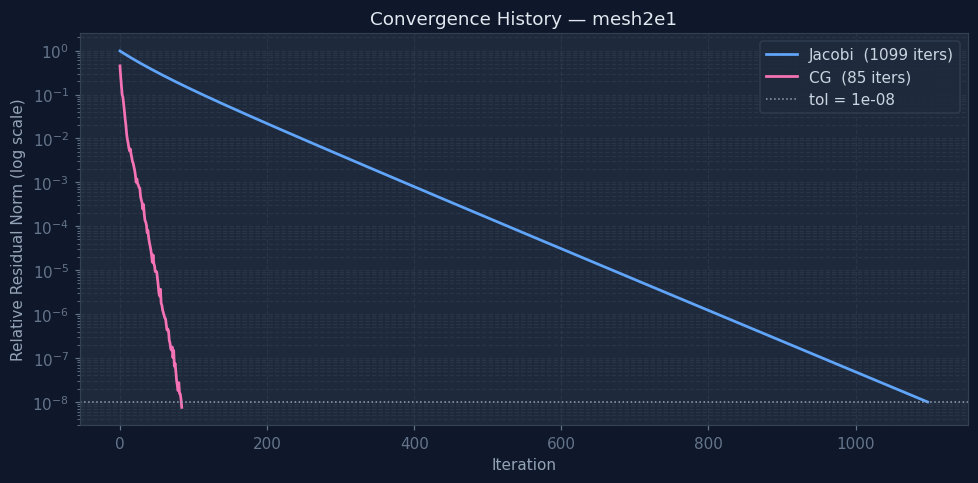

/tmp/ipykernel_393803/1731340096.py:32: RuntimeWarning: invalid value encountered in add
  x = D_inv.dot(b - A.dot(x) + d * x)


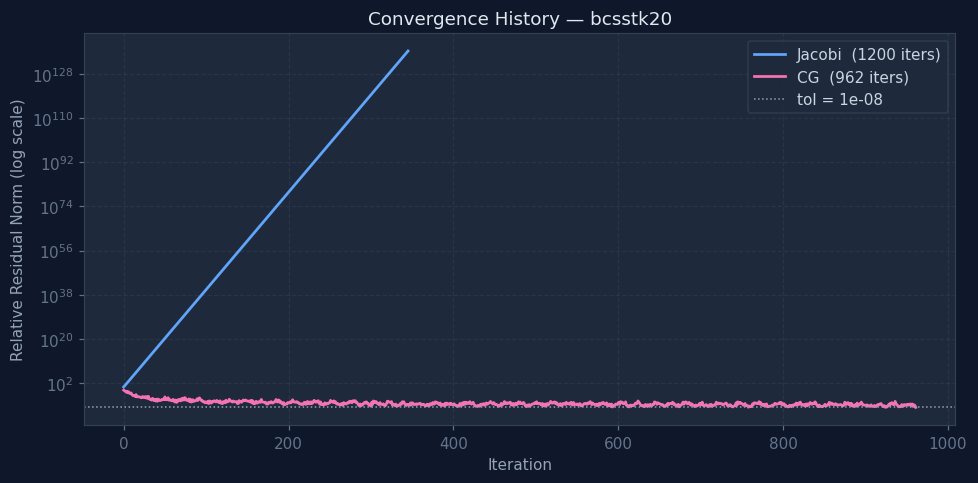

In [7]:
TOL, MAXIT = 1e-8, 1200

for name, A in zip(names_1, matrices_1):
    n       = A.shape[0]
    x_exact = np.ones(n)
    b       = A.dot(x_exact)
    x0      = np.zeros(n)

    # Jacobi
    _, it_j, res_j = jacobi(A, b, TOL, MAXIT, x0)

    # Conjugate Gradient
    res_cg = []
    def _cb(xk):
        res_cg.append(rel_residual_norm_iter(A, xk, b))
    try:
        cg(A, b, x0=x0, rtol=TOL, atol=TOL, maxiter=MAXIT, callback=_cb)
    except TypeError:
        cg(A, b, x0=x0, tol=TOL,  atol=TOL, maxiter=MAXIT, callback=_cb)
    res_cg = np.asarray(res_cg)

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.semilogy(res_j,  color=COLORS[0], lw=1.8, label=f'Jacobi  ({it_j} iters)')
    ax.semilogy(res_cg, color=COLORS[1], lw=1.8, label=f'CG  ({len(res_cg)} iters)')
    ax.axhline(TOL, color='#94a3b8', ls=':', lw=1, label=f'tol = {TOL}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Relative Residual Norm (log scale)')
    ax.set_title(f'Convergence History — {name}', fontsize=12)
    ax.legend()
    ax.grid(True, which='both')
    plt.tight_layout()
    plt.show()

 

### 2.3 · Interpretation

CG converges in $\mathcal{O}(\sqrt{\kappa})$ iterations for SPD systems, while Jacobi convergence depends on the spectral radius of the iteration matrix.

- **`mesh2e1`** is well-conditioned: both methods converge in a moderate number of iterations, with CG significantly outperforming Jacobi due to its optimal Krylov subspace construction.
- **`bcsstk20`** is severely ill-conditioned ($\kappa \sim 10^{12}$): Jacobi may stall or diverge, while CG still makes progress - though requiring many more iterations than for the well-conditioned problem.

> **Takeaway:** CG is robust against moderate ill-conditioning; Jacobi can fail entirely when the spectral radius of $I - D^{-1}A$ is close to 1.


---
## 3 · Preconditioned Conjugate Gradient (PCG)

Preconditioning replaces $Ax = b$ by $M^{-1}Ax = M^{-1}b$, targeting a reduced condition number $\kappa(M^{-1}A) \ll \kappa(A)$. Here we use the **Jacobi (diagonal) preconditioner** $M = D = \operatorname{diag}(A)$.


### 3.1 · PCG Implementation

The preconditioned CG algorithm applies $M^{-1}$ to the residual at each step:
$$z^{(k)} = M^{-1} r^{(k)}, \quad \alpha_k = \frac{r^{(k)\top} z^{(k)}}{p^{(k)\top} A p^{(k)}}, \quad \beta_k = \frac{r^{(k+1)\top} z^{(k+1)}}{r^{(k)\top} z^{(k)}}$$


In [8]:
def pcg(
    A: sp.sparse.spmatrix,
    b: np.ndarray,
    maxit: int,
    tol: float,
    x0: np.ndarray,
    prec=None,
) -> Tuple[np.ndarray, int, np.ndarray]:
    """
    Preconditioned Conjugate Gradient solver.

    Parameters
    ----------
    A     : (n, n) sparse SPD matrix
    b     : (n,) right-hand side
    maxit : maximum iterations
    tol   : convergence tolerance on rel_residual_norm_iter
    x0    : initial guess
    prec  : sparse preconditioner M⁻¹  (None → unpreconditioned CG)

    Returns
    -------
    x           : approximate solution
    iterations  : number of iterations performed
    rel_res_vec : residual history (length = iterations)
    """
    x  = x0.copy()
    r  = b - A.dot(x)
    z  = r.copy() if prec is None else prec.dot(r)
    p  = z.copy()
    rz = r.dot(z)

    history, k = [], 0
    for k in range(1, maxit + 1):
        Ap    = A.dot(p)
        alpha = rz / p.dot(Ap)
        x     = x + alpha * p
        r     = r - alpha * Ap

        res = rel_residual_norm_iter(A, x, b)
        history.append(res)
        if res < tol:
            break

        z      = r.copy() if prec is None else prec.dot(r)
        rz_new = r.dot(z)
        beta   = rz_new / rz
        p      = z + beta * p
        rz     = rz_new

    return x, k, np.asarray(history)


print('✓  pcg() defined.')


✓  pcg() defined.


### 3.2 · Effect of Preconditioning on Convergence


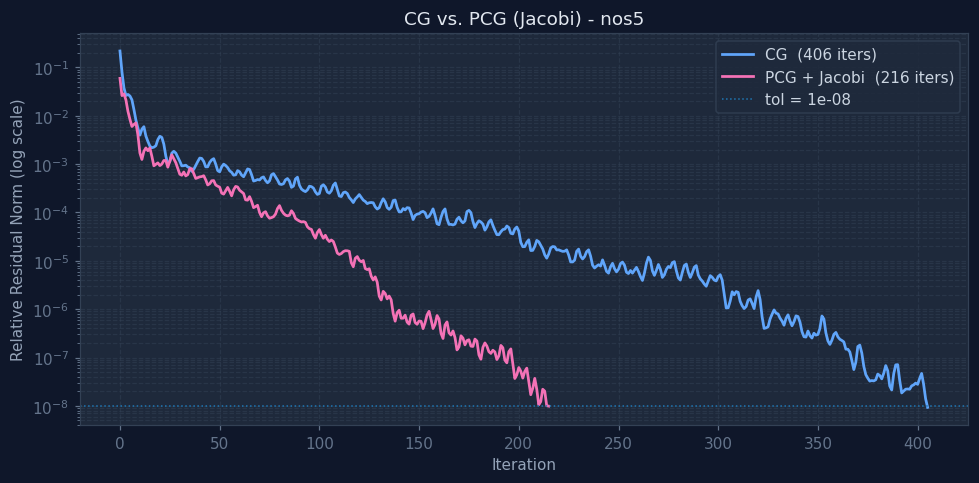

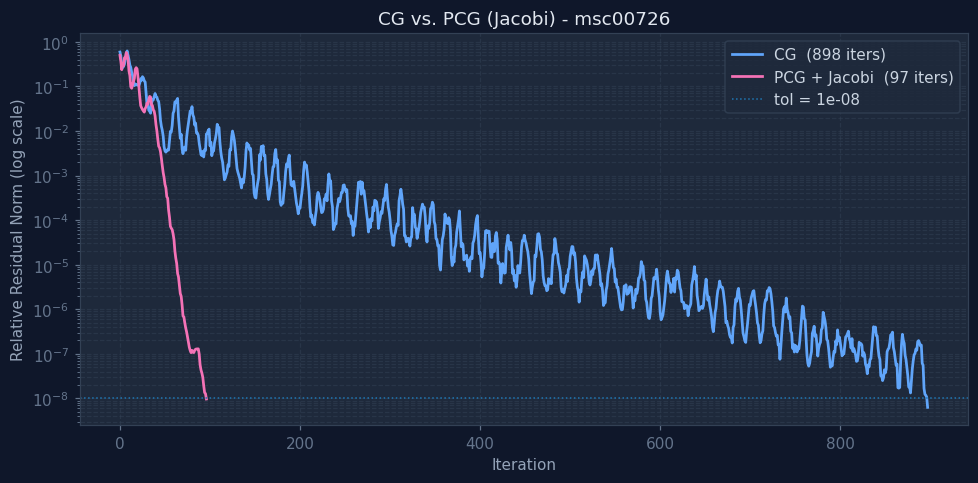

In [9]:
TOL, MAXIT = 1e-8, 1000

for name, A in zip(names_2, matrices_2):
    n       = A.shape[0]
    x_exact = np.ones(n)
    b       = A.dot(x_exact)
    x0      = np.zeros(n)

    # Build Jacobi preconditioner M⁻¹ = diag(A)⁻¹
    M_inv = sp.sparse.diags(1.0 / A.diagonal())

    _, it_cg,  res_cg  = pcg(A, b, MAXIT, TOL, x0, prec=None)
    _, it_pcg, res_pcg = pcg(A, b, MAXIT, TOL, x0, prec=M_inv)

    speedup = it_cg / it_pcg if it_pcg > 0 else float('inf')

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.semilogy(res_cg,  color=COLORS[0], lw=1.8, label=f'CG  ({it_cg} iters)')
    ax.semilogy(res_pcg, color=COLORS[1], lw=1.8, label=f'PCG + Jacobi  ({it_pcg} iters)')
    ax.axhline(TOL, ls=':', lw=1, label=f'tol = {TOL}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Relative Residual Norm (log scale)')
    ax.set_title(f'CG vs. PCG (Jacobi) - {name}', fontsize=12)
    ax.legend()
    ax.grid(True, which='both')
    plt.tight_layout()
    plt.show()



### 3.3 · Condition Numbers: Preconditioned vs. Unpreconditioned


In [10]:
print(f'{"Matrix":<12} {"κ₁(A)":>14} {"κ₁(M⁻¹A)":>14} {"Reduction":>12}')
print('-' * 56)

for name, A in zip(names_2, matrices_2):
    M_inv  = sp.sparse.diags(1.0 / A.diagonal())
    k_A    = cond_1(A.tocsc())
    k_MA   = cond_1(M_inv.dot(A).tocsc())
    factor = k_A / k_MA
    print(f'{name:<12} {k_A:>14.4e} {k_MA:>14.4e} {factor:>11.1f}×')


Matrix                κ₁(A)       κ₁(M⁻¹A)    Reduction
--------------------------------------------------------
nos5             2.9191e+04     8.0387e+03         3.6×
msc00726         1.2501e+06     9.0712e+03       137.8×


### 3.4 · Interpretation

The Jacobi preconditioner rescales each equation by the corresponding diagonal entry, normalising the matrix so that all diagonal elements become unity. This is most effective when $A$ is **diagonally dominant** - i.e., the diagonal captures most of the matrix's spectral energy.

- When $\kappa(M^{-1}A) \ll \kappa(A)$, PCG converges in far fewer iterations, as confirmed by the convergence plots.
- For matrices where off-diagonal entries are comparable in magnitude to the diagonal (weak diagonal dominance), the Jacobi preconditioner yields limited improvement; more powerful preconditioners such as ILU or AMG are then preferable.


---
## 4 · Summary & Conclusions


| Finding | Evidence |
|---------|----------|
| COLAMD ordering reduces LU fill-in significantly | §1.1 sparsity pattern plots |
| LU is backward stable; accuracy depends on $\kappa(A)$ | §1.2 error table |
| CG outperforms Jacobi, especially for ill-conditioned problems | §2.2 convergence plots |
| Jacobi preconditioning reduces $\kappa$ and iteration count | §3.3 condition number table |
